#  **Environment Setup & Dependencies**



In [1]:
# ==============================================================================
# INITIAL SETUP & DEPENDENCIES
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Install Linux system dependencies (CDO for climate data processing)
!apt-get install -y cdo libnetcdf-dev

# Install Python packages for handling climate and weather data formats
# cdsapi: To download data from the Copernicus Climate Data Store
# xarray & cfgrib: To read, analyze, and manipulate GRIB/NetCDF files
!pip install cdsapi xarray[complete] cfgrib netCDF4 dask numpy

Mounted at /content/drive
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libnetcdf-dev is already the newest version (1:4.8.1-1).
libnetcdf-dev set to manually installed.
The following additional packages will be installed:
  at-spi2-core binfmt-support blt fonts-dejavu-core fonts-dejavu-extra
  fonts-droid-fallback fonts-font-awesome fonts-lato fonts-lyx fonts-noto-mono
  fonts-urw-base35 ghostscript gsettings-desktop-schemas javascript-common
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libcdi0
  libclang-cpp11 libdouble-conversion3 libdxflib3 libeccodes-data libeccodes0
  libeckit0d libevdev2 libfftw3-double3 libgs9 libgs9-common libgtk-3-0
  libgtk-3-bin libgtk-3-common libgudev-1.0-0 libidn12 libijs-0.35
  libimagequant0 libinput-bin libinput10 libjbig2dec0 libjs-sphinxdoc
  libjs-underscore liblbfgsb0 libllvm11 liblzf1 libmagics++-data libmagplus3v5
  libmd4c0 libmtdev1 libodc-0d libpfm4 libproj22 libqt5core5a lib

In [2]:
import yaml
import os

config_file = 'config.yaml'

# 1. Initialization: Create config.yaml if it does not exist
if not os.path.exists(config_file):
    config_data = {
        'paths': {
            'root': '/content/drive/MyDrive/CERRA_processing',
            'cerra_data': '/content/drive/MyDrive/CERRA_Data',
            'remapped': '/content/drive/MyDrive/CERRA_processing/latlon_proj_Greece/remapped',
            'final': '/content/drive/MyDrive/CERRA_processing/final_standardized',
            'config': '/content/drive/MyDrive/CERRA_processing/config',
            'era5_raw': '/content/drive/MyDrive/ERA5_data',
            'combined': '/content/drive/MyDrive/ERA5_data/combined',
            'final_era5': "/content/drive/MyDrive/ERA5_data/final_standardized"
        },
        'api': {
            'url': 'https://cds.climate.copernicus.eu/api',
            'key': 'PASTE_YOUR_KEY_HERE'
        }
    }
    with open(config_file, 'w') as f:
        yaml.dump(config_data, f, default_flow_style=False)
    print("⚠️ config.yaml created. Please update it with your API Key!")
else:
    print("✅ config.yaml already exists.")

# 2. Loading: Load the configuration
with open(config_file, 'r') as f:
    cfg = yaml.safe_load(f)

# 3. Validation: Check if the API key is updated
if cfg['api']['key'] == 'PASTE_YOUR_KEY_HERE':
    print("❌ Warning: API Key is not configured yet.")
else:
    print("✅ Configuration loaded successfully.")

# **CERRA FILES**

### 1. **Directory Configuration**

In [ ]:
# ==============================================================================
# DIRECTORY CONFIGURATION
# ==============================================================================
import os
import yaml

# Load configuration from the YAML file
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Use the root path defined in the YAML configuration
base_path = cfg['paths']['root']
os.makedirs(base_path, exist_ok=True)
os.chdir(base_path)

print(f"Environment is ready. Working directory set to: {os.getcwd()}")

### 2. **Target Grid Definition (Cylindrical Projection Remapping)**

**Scientific Context:**
CERRA natively adopts a **conical projection** optimized for high latitudes. Conversely, ERA5 uses a **cylindrical projection**. To conduct a direct, pixel-by-pixel comparative analysis or downscaling over lower-latitude regions (such as the Mediterranean/Greece), a coordinate transformation is required.

We define a standardized **Regular Cylindrical Lat/Lon grid** (`gridtype = lonlat`) at a high resolution of $0.05^\circ \times 0.05^\circ$ (~5km) to serve as the common destination grid for the remapping process.

In [ ]:
# ==============================================================================
# GRID DEFINITION
# ==============================================================================
import os
import yaml

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

grid_content = """gridtype = lonlat
xsize    = 256
ysize    = 256
xfirst   = 17.0
xinc     = 0.05
yfirst   = 33.0
yinc     = 0.05
"""

# Use path from configuration
config_dir = cfg['paths']['config']
os.makedirs(config_dir, exist_ok=True)

grid_file_path = os.path.join(config_dir, "cyl_greece.txt")

with open(grid_file_path, "w") as f:
    f.write(grid_content)

print(f"Grid definition file created at: {grid_file_path}")

### 3.**Downloading Invariant Surface Constants (Orography & Land-Sea Mask)**

Before handling time-varying physical parameters, we download the invariant surface constants for our target period (2019). These files contain static topographical data (`orography`) and geographical boundaries (`land_sea_mask`) native to the CERRA Lambert Conformal Conic grid, which are vital for masking, verifying elevation adjustments, and establishing a baseline during the remapping process.

In [ ]:
# ==============================================================================
#  DOWNLOADING INVARIANT SURFACE CONSTANTS
# ==============================================================================
import os
import cdsapi
import shutil
import yaml
from google.colab import userdata

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# CDS API Setup
# Try to get key from Secrets (your case), otherwise from YAML (other users' case)
try:
    api_key = userdata.get('CDS_KEY')
except:
    api_key = cfg['api']['key']

cdsapi_rc = os.path.expanduser('~/.cdsapirc')
with open(cdsapi_rc, 'w') as f:
    f.write(f"url: {cfg['api']['url']}\n")
    f.write(f"key: {api_key}\n")

client = cdsapi.Client()

# Define paths from configuration
base_path = os.path.join(cfg['paths']['root'], "lambert_proj/single_levels")
os.makedirs(base_path, exist_ok=True)

lsm_path = os.path.join(base_path, "land_sea_mask.grib")
orog_path = os.path.join(base_path, "orography.grib")

# Request for Land-Sea Mask
print("Downloading Land-Sea Mask...")
request_lsm = {
    "variable": ["land_sea_mask"],
    "product_type": ["analysis"],
    "year": ["2019"],
    "month": ["01"],
    "day": ["01"],
    "time": ["00:00"],
    "data_format": "grib"
}
client.retrieve("reanalysis-cerra-single-levels", request_lsm, "temp_lsm.grib")
shutil.move("temp_lsm.grib", lsm_path)
print(f"Success: Land-Sea Mask saved to {lsm_path}")

# Request for Orography
print("Downloading Orography...")
request_orog = {
    "variable": ["orography"],
    "product_type": ["analysis"],
    "year": ["2019"],
    "month": ["01"],
    "day": ["01"],
    "time": ["00:00"],
    "data_format": "grib"
}
client.retrieve("reanalysis-cerra-single-levels", request_orog, "temp_orog.grib")
shutil.move("temp_orog.grib", orog_path)
print(f"Success: Orography saved to {orog_path}")

###  **Multi-Year Time-Series Extraction (2010 - 2021)**

This unified block automates the download of the 3-hourly $2\text{m}$ temperature dataset (`2m_temperature`) for the entire historical window from 2010 to 2021. To optimize execution and prevent Google Colab from running out of disk space, the data is processed in chronological annual batches. Each file is staged locally in the environment before being safely migrated to Google Drive.

In [ ]:
# ==============================================================================
# MULTI-YEAR TIME-SERIES EXTRACTION (2010 - 2021)
# ==============================================================================
import os
import cdsapi
import shutil
import yaml
from google.colab import userdata

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# CDS API Setup
try:
    api_key = userdata.get('CDS_KEY')
except:
    api_key = cfg['api']['key']

cdsapi_rc = os.path.expanduser('~/.cdsapirc')
with open(cdsapi_rc, 'w') as f:
    f.write(f"url: {cfg['api']['url']}\n")
    f.write(f"key: {api_key}\n")

client = cdsapi.Client()

# Path configuration
drive_base_path = cfg['paths']['cerra_data']
os.makedirs(drive_base_path, exist_ok=True)

years = [str(y) for y in range(2010, 2022)]
dataset = "reanalysis-cerra-single-levels"

# Download Loop
for year in years:
    print(f"\n--- Starting process for year: {year} ---")

    local_file = f"temp_{year}.grib"
    final_drive_path = os.path.join(drive_base_path, f"cerra_temp_{year}.grib")

    # Skip if file already exists to save time/bandwidth
    if os.path.exists(final_drive_path):
        print(f"File for {year} already exists. Skipping...")
        continue

    request = {
        "variable": ["2m_temperature"],
        "level_type": ["surface_or_atmosphere"],
        "data_type": ["reanalysis"],
        "product_type": ["analysis"],
        "year": [year],
        "month": [f"{m:02d}" for m in range(1, 13)],
        "day": [f"{d:02d}" for d in range(1, 32)],
        "time": ["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00"],
        "data_format": "grib"
    }

    try:
        print(f"Downloading {year} from CDS...")
        client.retrieve(dataset, request).download(local_file)

        print(f"Moving {year} to destination...")
        shutil.move(local_file, final_drive_path)
        print(f"✅ SUCCESS: {final_drive_path}")

    except Exception as e:
        print(f"❌ ERROR for {year}: {e}")

print("\n--- ALL YEARS COMPLETED ---")

###  **CDO System Initialization & Remapping**

In [ ]:

# ==============================================================================
# Purge mismatched repositories and install clean CDO binaries
!sudo add-apt-repository --remove ppa:ubuntugis/ppa -y
!apt-get update -qq
!apt-get install -y --fix-missing cdo
!ulimit -s unlimited

In [ ]:
# ==============================================================================
# CDO TEMPERATURE TIME-SERIES REMAPPING (GRIB TO NETCDF4)
# ==============================================================================
import os
import yaml
import subprocess

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Assign paths from configuration
grid_file = os.path.join(cfg['paths']['config'], "cyl_greece.txt")
input_dir = cfg['paths']['cerra_data']
output_dir = cfg['paths']['remapped']

if not os.path.exists(grid_file):
    print(f"Error: Grid file not found at {grid_file}")
else:
    os.makedirs(output_dir, exist_ok=True)
    all_files = [f for f in os.listdir(input_dir) if f.endswith(".grib")]
    print(f"Found {len(all_files)} files to process.")

    for f in sorted(all_files):
        in_p = os.path.join(input_dir, f)
        clean_name = f.replace("cerra_", "").replace(".grib", ".nc")
        out_p = os.path.join(output_dir, clean_name)

        if not os.path.exists(out_p):
            print(f"Processing: {f} -> {clean_name}")
            # Use subprocess for professional execution of CDO
            cmd = f"cdo -f nc4 -z zip_4 remapbil,{grid_file} {in_p} {out_p}"
            subprocess.run(cmd, shell=True, check=True)
        else:
            print(f"Skip: {clean_name} (already exists)")

print("\n--- REMAPPING COMPLETED ---")

In [ ]:
# ==============================================================================
# CLIPPING AFTER BILINEAR INTERPOLATION
# ==============================================================================
import os
import yaml
import subprocess

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Paths from configuration
grid_file = os.path.join(cfg['paths']['config'], "cyl_greece.txt")
input_file = os.path.join(cfg['paths']['root'], "lambert_proj/single_levels/orography.grib")
output_dir = cfg['paths']['remapped']
output_path = os.path.join(output_dir, "orography_clipped_after.nc")

if os.path.exists(grid_file) and os.path.exists(input_file):
    os.makedirs(output_dir, exist_ok=True)

    if not os.path.exists(output_path):
        print("Executing Approach A: Remap first, then clip negatives...")
        # Pipeline: Raw GRIB -> remapbil -> set negative range to missing -> convert missing to 0
        cmd = f"cdo -f nc4 -z zip_4 -setmisstoc,0 -setrtomiss,-999,0 -remapbil,{grid_file} {input_file} {output_path}"
        subprocess.run(cmd, shell=True, check=True)
        print(f"✅ Success: Output saved to {output_path}")
    else:
        print("Skip: Output already exists.")
else:
    print("Error: Grid file or Input file not found.")

In [ ]:
# ==============================================================================
# LAND-SEA MASK REMAPPING (Nearest Neighbor)
# ==============================================================================
import os
import yaml
import subprocess

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Paths from configuration
grid_file = os.path.join(cfg['paths']['config'], "cyl_greece.txt")
input_file = os.path.join(cfg['paths']['root'], "lambert_proj/single_levels/land_sea_mask.grib")
output_dir = cfg['paths']['remapped']
output_path = os.path.join(output_dir, "land_sea_mask.nc")

if os.path.exists(grid_file) and os.path.exists(input_file):
    os.makedirs(output_dir, exist_ok=True)

    if not os.path.exists(output_path):
        print("Processing: Remapping Land-Sea Mask...")
        # Use remapnn for binary masks (Nearest Neighbor)
        cmd = f"cdo -f nc4 -z zip_4 remapnn,{grid_file} {input_file} {output_path}"
        subprocess.run(cmd, shell=True, check=True)
        print(f"✅ Success: File saved to {output_path}")
    else:
        print("Skip: Land-Sea Mask already remapped.")
else:
    print("Error: Grid file or Input file not found.")

print("\n--- LAND-SEA MASK PROCESSING COMPLETED ---")

### **Metadata & Quality Inspector**





In [5]:
# ==============================================================================
# METADATA & QUALITY INSPECTOR
# ==============================================================================
import xarray as xr
import os
import glob
import numpy as np
import yaml

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Use the path from configuration
input_folder = cfg['paths']['remapped']
nc_files = sorted(glob.glob(os.path.join(input_folder, "*.nc")))

print(f"🔎 Found {len(nc_files)} files to inspect.\n")

for file_path in nc_files:
    file_name = os.path.basename(file_path)
    print(f"{'='*75}")
    print(f"📄 INSPECTING METADATA: {file_name}")
    print(f"{'='*75}")

    try:
        with xr.open_dataset(file_path) as ds:
            # Dynamic variable identification
            var_key = next((var for var in ds.data_vars
                            if any(k in var.lower() for k in ['2t', 't2m', 'temp', 'orog', 'elev', 'mask', 'lsm'])
                            or var.lower() in ['t', 'z']), list(ds.data_vars)[0])

            print(f"✅ CF Conventions: {ds.attrs.get('Conventions', 'N/A')}")

            print("\n📊 VARIABLE DATA & ATTRIBUTES:")
            for var in ds.data_vars:
                unit = ds[var].attrs.get('units', 'No units defined')
                long_name = ds[var].attrs.get('long_name', 'No description')
                print(f"   -> Variable: {var:10} | Units: {unit:12} | Info: {long_name}")

            print("-" * 40)

            # Dimensions & Shape
            print(f"📐 TARGET FIELD:        {var_key}")
            print(f"📐 SHAPE:               {ds[var_key].shape}")
            print(f"🔢 TOTAL GRID POINTS:   {ds[var_key].size:,}")

            # Time & Geography
            if 'time' in ds.coords:
                ds_sorted = ds.sortby('time')
                print(f"📅 TIME HORIZON:        {np.datetime_as_string(ds_sorted.time.values[0], unit='h')} to "
                      f"{np.datetime_as_string(ds_sorted.time.values[-1], unit='h')} ({len(ds.time)} steps)")
            else:
                print("📅 TIME HORIZON:        Static Spatial Invariant")

            lat_name, lon_name = ('lat', 'lon') if 'lat' in ds.coords else ('latitude', 'longitude')
            print(f"📍 LAT RANGE:           {float(ds[lat_name].min()):.3f}°N to {float(ds[lat_name].max()):.3f}°N")
            print(f"📍 LON RANGE:           {float(ds[lon_name].min()):.3f}°E to {float(ds[lon_name].max()):.3f}°E")

            # Data Metrics
            v_min, v_max, v_mean = float(ds[var_key].min()), float(ds[var_key].max()), float(ds[var_key].mean())
            print(f"🌡️ DATA METRICS:        Min: {v_min:.2f} | Max: {v_max:.2f} | Mean: {v_mean:.2f}")

    except Exception as e:
        print(f"❌ ERROR processing file {file_name}: {e}")

    print("\n")

print("--- ALL NC FILES SUCCESSFULLY VERIFIED ---")

🔎 Found 14 files to inspect.

📄 INSPECTING METADATA: land_sea_mask.nc
✅ CF Conventions: CF-1.6

📊 VARIABLE DATA & ATTRIBUTES:
   -> Variable: lsm        | Units: (0 - 1)      | Info: Land-sea mask
----------------------------------------
📐 TARGET FIELD:        lsm
📐 SHAPE:               (1, 256, 256)
🔢 TOTAL GRID POINTS:   65,536
📅 TIME HORIZON:        2019-01-01T00 to 2019-01-01T00 (1 steps)
📍 LAT RANGE:           33.000°N to 45.750°N
📍 LON RANGE:           17.000°E to 29.750°E
🌡️ DATA METRICS:        Min: 0.00 | Max: 1.00 | Mean: 0.47


📄 INSPECTING METADATA: orography_clipped_after.nc
✅ CF Conventions: CF-1.6

📊 VARIABLE DATA & ATTRIBUTES:
   -> Variable: orog       | Units: m            | Info: Orography
----------------------------------------
📐 TARGET FIELD:        orog
📐 SHAPE:               (1, 256, 256)
🔢 TOTAL GRID POINTS:   65,536
📅 TIME HORIZON:        2019-01-01T00 to 2019-01-01T00 (1 steps)
📍 LAT RANGE:           33.000°N to 45.750°N
📍 LON RANGE:           17.000°E to 29.

### **Preprocess Cerra**

In [ ]:
!pip install cftime==1.6.4 netCDF4 xarray

In [ ]:
# ==============================================================================
# FINAL DATA STANDARDIZATION & CF-COMPLIANCE PIPELINE
# ==============================================================================
import os
import xarray as xr
import numpy as np
import yaml

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Use configuration paths
input_dir = cfg['paths']['remapped']
output_dir = cfg['paths']['final']
os.makedirs(output_dir, exist_ok=True)

years = range(2010, 2022)

# ------------------------------------------------------------------------------
# STEP 1: METEOROLOGICAL VARIABLES (TEMPERATURE)
# ------------------------------------------------------------------------------
t2m_encoding = {
    't2m': {'zlib': True, 'complevel': 5, 'chunksizes': (1, 256, 256)},
    'time': {'units': 'hours since 1900-01-01 00:00:00', 'calendar': 'proleptic_gregorian'}
}

for year in years:
    file_path = os.path.join(input_dir, f"temp_{year}.nc")
    if not os.path.exists(file_path):
        print(f"⚠️ Warning: temp_{year}.nc not found. Skipping...")
        continue

    print(f"🔄 Standardizing Temperature for year: {year}...")
    with xr.open_dataset(file_path) as ds:
        ds = ds.sortby('time').squeeze(drop=True)

        # Rename variables for CF compliance
        rename_dict = {'2t': 't2m', 'lat': 'latitude', 'lon': 'longitude'}
        ds = ds.rename({k: v for k, v in rename_dict.items() if k in ds.variables or k in ds.coords})

        # Integrity check
        is_leap = (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)
        samples = 2928 if is_leap else 2920
        if len(ds.time) != samples:
            print(f"🚨 Integrity Warning: Year {year} has {len(ds.time)} steps.")

        save_path = os.path.join(output_dir, f"CERRA_Greece_{year}.nc")
        ds.to_netcdf(save_path, encoding=t2m_encoding)
        print(f"✅ Saved Standardized Year {year}!")

# ------------------------------------------------------------------------------
# STEP 2: STATIC INVARIANTS (OROGRAPHY & LAND-SEA MASK)
# ------------------------------------------------------------------------------
static_files = {
    "orography": {"in": "orography_clipped_after.nc", "out": "CERRA_orography_static.nc", "var": "orography"},
    "lsm": {"in": "land_sea_mask.nc", "out": "CERRA_land_sea_mask.nc", "var": "land_mask"}
}

for key, info in static_files.items():
    s_path = os.path.join(input_dir, info["in"])
    if os.path.exists(s_path):
        print(f"🔄 Standardizing {key}...")
        with xr.open_dataset(s_path) as ds:
            ds = ds.squeeze(drop=True)
            if 'time' in ds.coords: ds = ds.drop_vars('time')

            # Apply standard attributes
            ds.attrs.update({'Conventions': 'CF-1.8', 'title': f'Standardized {key}'})

            save_path = os.path.join(output_dir, info["out"])
            ds.to_netcdf(save_path, encoding={info['var']: {'zlib': True, 'complevel': 5, 'chunksizes': (256, 256)}})
            print(f"🚀 {key} saved successfully!")
    else:
        print(f"❌ Error: {info['in']} not found!")

print("\n🎉 ALL FILES STANDARDIZED AND SAVED!")

# **ERA5 FILES**





### **ERA5 Single Levels Data Downloader**

In [ ]:
# ==============================================================================
# ERA5 DATA RETRIEVAL: SINGLE LEVELS (3-HOURLY RESOLUTION)
# ==============================================================================
import os
import cdsapi
import yaml
from google.colab import userdata

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# CDS API Setup (Secure)
try:
    api_key = userdata.get('CDS_KEY')
except:
    api_key = cfg['api']['key']

# Use standard path for cdsapirc
with open(os.path.expanduser('~/.cdsapirc'), 'w') as f:
    f.write(f"url: {cfg['api']['url']}\n")
    f.write(f"key: {api_key}\n")

c = cdsapi.Client()

# Path configuration from YAML
output_dir = cfg['paths']['era5_raw']
os.makedirs(output_dir, exist_ok=True)

years = [str(y) for y in range(2010, 2022)]

for year in years:
    output_filename = os.path.join(output_dir, f"era5_raw_{year}.nc")

    print(f"\n--- Starting download workflow for Year: {year} ---")

    if os.path.exists(output_filename):
        print(f"File {output_filename} already exists. Skipping...")
        continue

    try:
        c.retrieve(
            'reanalysis-era5-single-levels',
            {
                'product_type': 'reanalysis',
                'format': 'netcdf',
                'variable': [
                    '10m_u_component_of_wind',
                    '10m_v_component_of_wind',
                    '2m_temperature',
                ],
                'year': year,
                'month': [f"{m:02d}" for m in range(1, 13)],
                'day': [f"{d:02d}" for d in range(1, 32)],
                'time': ['00:00', '03:00', '06:00', '09:00', '12:00', '15:00', '18:00', '21:00'],
                'area': [45.75, 17.0, 33.0, 29.75],
            },
            output_filename
        )
        print(f"✅ Download Successful: {output_filename}")

    except Exception as e:
        print(f"❌ API Error for Year {year}: {e}")

print("\n--- ALL ERA5 DOWNLOADS COMPLETED ---")

In [ ]:
# ==============================================================================
# ERA5 DATA RETRIEVAL: SINGLE LEVELS (2m Dewpoint Temperature)
# ==============================================================================
import os
import cdsapi
import yaml
from google.colab import userdata

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# CDS API Setup (Secure)
try:
    api_key = userdata.get('CDS_KEY')
except:
    api_key = cfg['api']['key']

# Configure CDS API access
with open(os.path.expanduser('~/.cdsapirc'), 'w') as f:
    f.write(f"url: {cfg['api']['url']}\n")
    f.write(f"key: {api_key}\n")

client = cdsapi.Client()

# Path configuration from YAML
output_dir = cfg['paths']['era5_raw']
os.makedirs(output_dir, exist_ok=True)

years = [str(y) for y in range(2010, 2022)]

for year in years:
    output_filename = os.path.join(output_dir, f"era5_2dew_{year}.nc")

    print(f"\n--- Starting download workflow for Year: {year} ---")

    if os.path.exists(output_filename):
        print(f"File {output_filename} already exists. Skipping...")
        continue

    try:
        client.retrieve(
            'reanalysis-era5-single-levels',
            {
                'product_type': 'reanalysis',
                'format': 'netcdf',
                'variable': ['2m_dewpoint_temperature'],
                'year': year,
                'month': [f"{m:02d}" for m in range(1, 13)],
                'day': [f"{d:02d}" for d in range(1, 32)],
                'time': ['00:00', '03:00', '06:00', '09:00', '12:00', '15:00', '18:00', '21:00'],
                'area': [45.75, 17.0, 33.0, 29.75],
            },
            output_filename
        )
        print(f"✅ Download Successful: {output_filename}")

    except Exception as e:
        print(f"❌ API Error for Year {year}: {e}")

print("\n--- ALL ERA5 DEWPOINT DOWNLOADS COMPLETED ---")

### **ERA5 Pressure Levels Data Downloader (850 hPa)**

In [ ]:
# ==============================================================================
# ERA5 DATA RETRIEVAL: UPPER-AIR PRESSURE LEVELS (850hPa Temperature)
# ==============================================================================
import os
import cdsapi
import yaml
from google.colab import userdata

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# CDS API Setup (Secure)
try:
    api_key = userdata.get('CDS_KEY')
except:
    api_key = cfg['api']['key']

# Configure CDS API access
with open(os.path.expanduser('~/.cdsapirc'), 'w') as f:
    f.write(f"url: {cfg['api']['url']}\n")
    f.write(f"key: {api_key}\n")

client = cdsapi.Client()

# Path configuration from YAML
output_dir = cfg['paths']['era5_raw']
os.makedirs(output_dir, exist_ok=True)

years = [str(y) for y in range(2010, 2022)]

for year in years:
    output_filename = os.path.join(output_dir, f"era5_temp850_{year}.nc")

    print(f"\n--- Starting upper-air download workflow for Year: {year} ---")

    if os.path.exists(output_filename):
        print(f"File {output_filename} already exists. Skipping...")
        continue

    try:
        client.retrieve(
            'reanalysis-era5-pressure-levels',
            {
                'product_type': 'reanalysis',
                'format': 'netcdf',
                'variable': ['temperature'],
                'pressure_level': ['850'],
                'year': year,
                'month': [f"{m:02d}" for m in range(1, 13)],
                'day': [f"{d:02d}" for d in range(1, 32)],
                'time': ['00:00', '03:00', '06:00', '09:00', '12:00', '15:00', '18:00', '21:00'],
                'area': [45.75, 17.0, 33.0, 29.75],
            },
            output_filename
        )
        print(f"✅ Download Successful: {output_filename}")

    except Exception as e:
        print(f"❌ API Error for Year {year}: {e}")

print("\n--- ALL UPPER-AIR DOWNLOADS COMPLETED ---")

In [ ]:
# ==============================================================================
# RAW MERGING OF ALL ERA5 FILES PER YEAR
# ==============================================================================
import os
import xarray as xr
import yaml

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

era5_dir = cfg['paths']['era5_raw']
years = range(2010, 2022)

for year in years:
    print(f"🔄 Merging raw files for year: {year}...")

    # Define paths
    paths = {
        "raw": os.path.join(era5_dir, f"era5_raw_{year}.nc"),
        "dew": os.path.join(era5_dir, f"era5_2dew_{year}.nc"),
        "t850": os.path.join(era5_dir, f"era5_temp850_{year}.nc")
    }
    output_filename = os.path.join(era5_dir, f"era5_combined_raw_{year}.nc")

    # Check if all files exist
    if all(os.path.exists(p) for p in paths.values()):
        try:
            # Use a list of datasets with context managers to ensure memory safety
            with xr.open_dataset(paths["raw"]) as ds_raw, \
                 xr.open_dataset(paths["dew"]) as ds_dew, \
                 xr.open_dataset(paths["t850"]) as ds_t850:

                # Merge datasets
                ds_merged = xr.merge([ds_raw, ds_dew, ds_t850])

                # Save to disk
                ds_merged.to_netcdf(output_filename)
                print(f"✅ Year {year} merged successfully!")

        except Exception as e:
            print(f"❌ Error merging year {year}: {e}")
    else:
        print(f"⚠️ Skipping {year}: Missing one or more input files.")

print("\n🚀 ALL YEARS MERGED SUCCESSFULLY!")

### **Metadata & Quality Inspector**





In [8]:
# ==============================================================================
# ERA5 MULTI-FILE METADATA INSPECTOR
# ==============================================================================
import xarray as xr
import os
import glob
import yaml

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Use configuration path
input_folder = cfg['paths']['era5_raw']
nc_files = sorted(glob.glob(os.path.join(input_folder, "*.nc")))

print(f"🔎 Found {len(nc_files)} ERA5 files to inspect.\n")

for file_path in nc_files:
    file_name = os.path.basename(file_path)
    print(f"{'='*70}\n📄 CHECKING ERA5 FILE: {file_name}\n{'='*70}")

    try:
        with xr.open_dataset(file_path) as ds:
            print(f"✅ NetCDF Conventions: {ds.attrs.get('Conventions', 'N/A')}")
            print("\n📊 VARIABLES FOUND:")
            for var in ds.data_vars:
                unit = ds[var].attrs.get('units', 'N/A')
                print(f"   -> {var:15} | Units: {unit:10} | Shape: {ds[var].shape}")

            # Time identification
            time_name = next((t for t in ['time', 'valid_time'] if t in ds.coords), None)
            if time_name:
                print(f"\n📅 TIME STEPS:  {len(ds[time_name])}")
                print(f"📅 DATE RANGE:  {ds[time_name].values[0]} to {ds[time_name].values[-1]}")
            else:
                print("⚠️ TIME COORDINATE NOT FOUND!")

            # Geo identification
            lat_n, lon_n = ('latitude', 'longitude') if 'latitude' in ds.coords else ('lat', 'lon')
            if lat_n in ds.coords and lon_n in ds.coords:
                print(f"📍 LAT RANGE:   {ds[lat_n].values.min():.2f}° to {ds[lat_n].values.max():.2f}°")
                print(f"📍 LON RANGE:   {ds[lon_n].values.min():.2f}° to {ds[lon_n].values.max():.2f}°")
                if len(ds[lat_n]) > 1:
                    res = abs(ds[lat_n].values[1] - ds[lat_n].values[0])
                    print(f"📏 GRID RES:    {res:.2f}°")
            else:
                print("⚠️ GEOGRAPHICAL COORDINATES NOT FOUND!")

    except Exception as e:
        print(f"❌ ERROR reading {file_name}: {e}")
    print("\n")

print("--- FINISHED SCANNING ---")

🔎 Found 48 ERA5 files to inspect.

📄 CHECKING ERA5 FILE: era5_2dew_2010.nc
✅ NetCDF Conventions: CF-1.7

📊 VARIABLES FOUND:
   -> d2m             | Units: K          | Shape: (2920, 52, 52)

📅 TIME STEPS:  2920
📅 DATE RANGE:  2010-01-01T00:00:00.000000000 to 2010-12-31T21:00:00.000000000
📍 LAT RANGE:   33.00° to 45.75°
📍 LON RANGE:   17.00° to 29.75°
📏 GRID RES:    0.25°


📄 CHECKING ERA5 FILE: era5_2dew_2011.nc
✅ NetCDF Conventions: CF-1.7

📊 VARIABLES FOUND:
   -> d2m             | Units: K          | Shape: (2920, 52, 52)

📅 TIME STEPS:  2920
📅 DATE RANGE:  2011-01-01T00:00:00.000000000 to 2011-12-31T21:00:00.000000000
📍 LAT RANGE:   33.00° to 45.75°
📍 LON RANGE:   17.00° to 29.75°
📏 GRID RES:    0.25°


📄 CHECKING ERA5 FILE: era5_2dew_2012.nc
✅ NetCDF Conventions: CF-1.7

📊 VARIABLES FOUND:
   -> d2m             | Units: K          | Shape: (2928, 52, 52)

📅 TIME STEPS:  2928
📅 DATE RANGE:  2012-01-01T00:00:00.000000000 to 2012-12-31T21:00:00.000000000
📍 LAT RANGE:   33.00° to 45.7

### **Preprocessing ERA5**

In [ ]:
# ==============================================================================
# ERA5 DATA STANDARDIZATION & CF-COMPLIANCE
# ==============================================================================
import xarray as xr
import pandas as pd
import os
import yaml

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Paths from configuration
input_dir = cfg['paths']['era5_raw']
output_dir = cfg['paths']['final_era5']
os.makedirs(output_dir, exist_ok=True)

years = range(2010, 2022)

# Standardized Encoding
my_encoding = {
    var: {'zlib': True, 'complevel': 5, 'chunksizes': (1, 52, 52)}
    for var in ['t2m', 'u10', 'v10', 'd2m', 't850']
}
my_encoding['time'] = {'units': 'hours since 1900-01-01 00:00:00', 'calendar': 'proleptic_gregorian'}

for year in years:
    file_path = os.path.join(input_dir, f"era5_combined_raw_{year}.nc")
    if not os.path.exists(file_path):
        print(f"⚠️ Warning: {file_path} not found. Skipping...")
        continue

    print(f"🔄 Standardizing ERA5 {year}...")

    with xr.open_dataset(file_path) as ds:
        ds = ds.squeeze(drop=True)

        # CF-Compliance Renaming
        rename_map = {'valid_time': 'time', 't': 't850', 'lat': 'latitude', 'lon': 'longitude'}
        ds = ds.rename({k: v for k, v in rename_map.items() if k in ds.variables or k in ds.coords})

        # Integrity & Time Correction
        is_leap = (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)
        samples = 2928 if is_leap else 2920
        ds['time'] = pd.date_range(start=f"{year}-01-01 00:00:00", periods=samples, freq='3H')

        # Add Metadata
        ds.attrs.update({'Conventions': 'CF-1.8', 'title': f'Standardized ERA5 Predictors ({year})'})

        if 'd2m' in ds.data_vars:
            ds['d2m'].attrs.update({'standard_name': 'dew_point_temperature', 'units': 'K'})
        if 't850' in ds.data_vars:
            ds['t850'].attrs.update({'standard_name': 'air_temperature', 'units': 'K'})

        # Save
        save_path = os.path.join(output_dir, f"ERA5_Greece_{year}_52x52.nc")
        ds.to_netcdf(save_path, encoding=my_encoding)
        print(f"✅ Finished {year}!")

print("\n🚀 All ERA5 files standardized to CF-1.8!")

# **PREPARING CERRA & ERA5 TENSORS FOR DEEP LEARNING (B, C, H, W) FORMAT**

### **ERA5 Concatenation**

In [ ]:
# ==============================================================================
# ERA5 FULL TIME-SERIES CONCATENATION (2010-2021)
# ==============================================================================
import os
import glob
import xarray as xr
import yaml

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Use configuration paths
input_folder = cfg['paths']['final_era5']
output_dir = cfg['paths']['combined']
os.makedirs(output_dir, exist_ok=True)

# Gather and sort files
file_list = sorted(glob.glob(os.path.join(input_folder, "ERA5_Greece_*_52x52.nc")))

if not file_list:
    raise FileNotFoundError(f"No standardized files found in {input_folder}!")

print(f"Found {len(file_list)} files. Combining into a single time-series...")

# Open all files as a single virtual dataset
with xr.open_mfdataset(file_list, combine='nested', concat_dim='time', chunks={'time': 500}) as ds_era5:

    # Define dynamic encoding for all variables in the merged dataset
    save_encoding = {
        var: {'zlib': True, 'complevel': 5, 'chunksizes': (1, 52, 52)}
        for var in ds_era5.data_vars
    }
    save_encoding['time'] = {'units': 'hours since 1900-01-01 00:00:00', 'calendar': 'proleptic_gregorian'}

    final_path = os.path.join(output_dir, "ERA5_2010_2021_combined.nc")

    print(f"Writing combined NetCDF to: {final_path}")
    ds_era5.to_netcdf(final_path, encoding=save_encoding)

print(f"\n🚀 SUCCESS: Full time-series dataset created at {final_path}")

### **Cerra Concatenation**

In [ ]:
# ==============================================================================
# CERRA FULL TIME-SERIES CONCATENATION (2010-2021)
# ==============================================================================
import os
import glob
import xarray as xr
import yaml

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Paths from configuration
input_folder = cfg['paths']['final']
output_dir = cfg['paths']['root'] # Saving the combined file in the root
os.makedirs(output_dir, exist_ok=True)

# Gather and sort yearly files, ignoring static invariants (orography/mask)
file_list = sorted(glob.glob(os.path.join(input_folder, "CERRA_Greece_2*.nc")))

if not file_list:
    raise FileNotFoundError(f"No standardized yearly CERRA files found in {input_folder}!")

print(f"Found {len(file_list)} files. Concatenating into a single time-series...")

# Open and combine as a single dataset
with xr.open_mfdataset(file_list, combine='nested', concat_dim='time', chunks={'time': 500}) as ds_cerra:

    # Define dynamic encoding
    save_encoding = {
        var: {'zlib': True, 'complevel': 5, 'chunksizes': (1, len(ds_cerra.latitude), len(ds_cerra.longitude))}
        for var in ds_cerra.data_vars
    }
    if 'time' in ds_cerra.coords:
        save_encoding['time'] = {
            'units': 'hours since 1900-01-01 00:00:00',
            'calendar': 'proleptic_gregorian'
        }

    final_path = os.path.join(output_dir, "Cerra_2010_2021_combined.nc")

    print(f"Writing combined NetCDF to: {final_path}")
    ds_cerra.to_netcdf(final_path, encoding=save_encoding)

print(f"\n🚀 SUCCESS: Full CERRA time-series created at {final_path}")

In [ ]:
# ==============================================================================
# CERRA STATIC FIELDS CONCATENATION (Orography & Mask)
# ==============================================================================
import os
import glob
import xarray as xr
import yaml

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

input_dir = cfg['paths']['final']
output_dir = cfg['paths']['root']
final_static_path = os.path.join(output_dir, "CERRA_Greece_Static_CHW.nc")

print("🔎 Searching for static fields...")

# Automatically identify files
orog_files = glob.glob(os.path.join(input_dir, "*orog*"))
lsm_files = glob.glob(os.path.join(input_dir, "*land*")) + glob.glob(os.path.join(input_dir, "*lsm*"))

if not orog_files or not lsm_files:
    raise FileNotFoundError("Static files (orography/land-sea mask) not found.")

with xr.open_dataset(orog_files[0]) as ds_orog, xr.open_dataset(lsm_files[0]) as ds_lsm:

    # Merge datasets
    ds_combined = xr.merge([ds_orog, ds_lsm])

    # Identify variables dynamically
    v_orog = next(v for v in ds_combined.data_vars if 'orog' in v)
    v_lsm = next(v for v in ds_combined.data_vars if 'land' in v or 'lsm' in v)

    # Stack into a single channel dimension
    ds_static_final = ds_combined[[v_orog, v_lsm]].to_array(dim='channel')
    ds_static_final = ds_static_final.transpose('channel', 'latitude', 'longitude').to_dataset(name='static_data')

    # Save output
    ds_static_final.to_netcdf(final_static_path)
    print(f"✅ Success! Static fields stacked and saved at: {final_static_path}")
    print(f"📐 Final static shape (Channels, Lat, Lon): {ds_static_final.static_data.shape}")

### Data Reshaping to BCHW format

In [ ]:
# ==============================================================================
# ERA5 TENSOR TRANSFORMATION TO BCHW FORMAT (5 Channels)
# ==============================================================================
import xarray as xr
import os
import yaml

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Paths
combined_file = os.path.join(cfg['paths']['combined'], "ERA5_2010_2021_combined.nc")
final_bchw = os.path.join(cfg['paths']['combined'], "ERA5_2010_2021_BCHW.nc")

print("🔄 Transforming ERA5 to BCHW for Deep Learning...")

with xr.open_dataset(combined_file) as ds:
    # Select variables and stack into channels
    variables = ['t2m', 'u10', 'v10', 'd2m', 't850']
    da_stacked = ds[variables].to_array(dim='channel')

    # Transpose to (Time, Channel, Latitude, Longitude) -> (T, C, H, W)
    ds_final = da_stacked.transpose('time', 'channel', 'latitude', 'longitude').to_dataset(name='era5_data')

    # Define optimized encoding
    encoding = {
        'era5_data': {
            'zlib': True,
            'complevel': 5,
            'chunksizes': (1, 5, 52, 52)
        }
    }

    # Save output
    ds_final.to_netcdf(final_bchw, encoding=encoding)
    print(f"✅ Final BCHW Tensor Shape: {ds_final.era5_data.shape}")
    print(f"🚀 Saved to: {final_bchw}")

In [ ]:
# ==============================================================================
# CERRA TENSOR TRANSFORMATION TO BCHW FORMAT (1 Channel: t2m)
# ==============================================================================
import xarray as xr
import os
import yaml

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Paths
combined_file = os.path.join(cfg['paths']['root'], "Cerra_2010_2021_combined.nc")
final_bchw = os.path.join(cfg['paths']['root'], "Cerra_2010_2021_BCHW.nc")

print("🔄 Transforming CERRA into BCHW for Deep Learning...")

# Open with chunks for memory efficiency
with xr.open_dataset(combined_file, chunks={'time': 100}) as ds:
    # Expand dims to add channel axis (B=Time, C=Channel, H=Lat, W=Lon)
    da_bchw = ds['t2m'].expand_dims(dim='channel', axis=1)
    ds_final = da_bchw.to_dataset(name='cerra_data')

    # Encoding for optimized storage
    encoding = {
        'cerra_data': {
            'zlib': True,
            'complevel': 5,
            'chunksizes': (1, 1, 256, 256)
        }
    }

    print(f"📐 Final CERRA Tensor Shape (B, C, H, W): {ds_final.cerra_data.shape}")
    print("💾 Writing to disk...")

    ds_final.to_netcdf(final_bchw, encoding=encoding)

print(f"✅ CERRA BCHW dataset is officially ready at: {final_bchw}")

In [ ]:
# ==============================================================================
# CERRA STATIC FIELDS CONCATENATION (B=1, C=2, H=256, W=256)
# ==============================================================================
import os
import glob
import xarray as xr
import yaml

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

input_dir = cfg['paths']['final']
output_dir = cfg['paths']['root']
final_static_path = os.path.join(output_dir, "CERRA_Greece_Static_B1_CHW.nc")

print("🔎 Searching for static fields...")
orog_files = glob.glob(os.path.join(input_dir, "*orog*"))
lsm_files = glob.glob(os.path.join(input_dir, "*land*")) + glob.glob(os.path.join(input_dir, "*lsm*"))

if not orog_files or not lsm_files:
    raise FileNotFoundError("Static files (orography/land-sea mask) not found.")

with xr.open_dataset(orog_files[0]) as ds_orog, xr.open_dataset(lsm_files[0]) as ds_lsm:
    ds_combined = xr.merge([ds_orog, ds_lsm])

    # Identify variables
    v_orog = next(v for v in ds_combined.data_vars if 'orog' in v)
    v_lsm = next(v for v in ds_combined.data_vars if 'lsm' in v or 'land' in v)

    # Stack channels and add Batch dimension (B=1)
    da_stacked = ds_combined[[v_orog, v_lsm]].to_array(dim='channel')
    if 'time' in da_stacked.dims:
        da_stacked = da_stacked.squeeze(dim='time', drop=True)

    da_padded = da_stacked.expand_dims(dim={'time': 1}, axis=0)
    ds_static_final = da_padded.transpose('time', 'channel', 'latitude', 'longitude').to_dataset(name='static_data')

    # Save output
    ds_static_final.to_netcdf(final_static_path)
    print(f"✅ Success! Static fields stacked (B1-CHW) saved at: {final_static_path}")
    print(f"📐 Final shape (B, C, H, W): {ds_static_final.static_data.shape}")

# **INSPECTING FINAL FILES**

In [9]:
# ==============================================================================
# FINAL PIPELINE INTEGRITY INSPECTOR
# ==============================================================================
import xarray as xr
import os
import yaml

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Path mapping
datasets = {
    "ERA5 BCHW": os.path.join(cfg['paths']['combined'], "ERA5_2010_2021_BCHW.nc"),
    "CERRA BCHW": os.path.join(cfg['paths']['root'], "Cerra_2010_2021_BCHW.nc"),
    "Static Fields": os.path.join(cfg['paths']['root'], "CERRA_Greece_Static_B1_CHW.nc")
}

print(f"🔎 INSPECTING FINAL TENSOR SHAPES\n{'='*60}")

for name, path in datasets.items():
    if os.path.exists(path):
        with xr.open_dataset(path) as ds:
            # Get the first data variable name dynamically
            var_name = list(ds.data_vars)[0]
            shape = ds[var_name].shape

            print(f"📊 {name}")
            print(f"   Shape (B, C, H, W): {shape}")
            print(f"   Time steps        : {shape[0]}")
            print(f"   Channels          : {shape[1]}")
            print("-" * 30)
    else:
        print(f"❌ {name} file NOT FOUND at: {path}")

print("✅ Inspection completed successfully!")

🔎 INSPECTING FINAL TENSOR SHAPES
📊 ERA5 BCHW
   Shape (B, C, H, W): (35064, 5, 52, 52)
   Time steps        : 35064
   Channels          : 5
------------------------------
📊 CERRA BCHW
   Shape (B, C, H, W): (35064, 1, 256, 256)
   Time steps        : 35064
   Channels          : 1
------------------------------
📊 Static Fields
   Shape (B, C, H, W): (1, 2, 256, 256)
   Time steps        : 1
   Channels          : 2
------------------------------
✅ Inspection completed successfully!


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


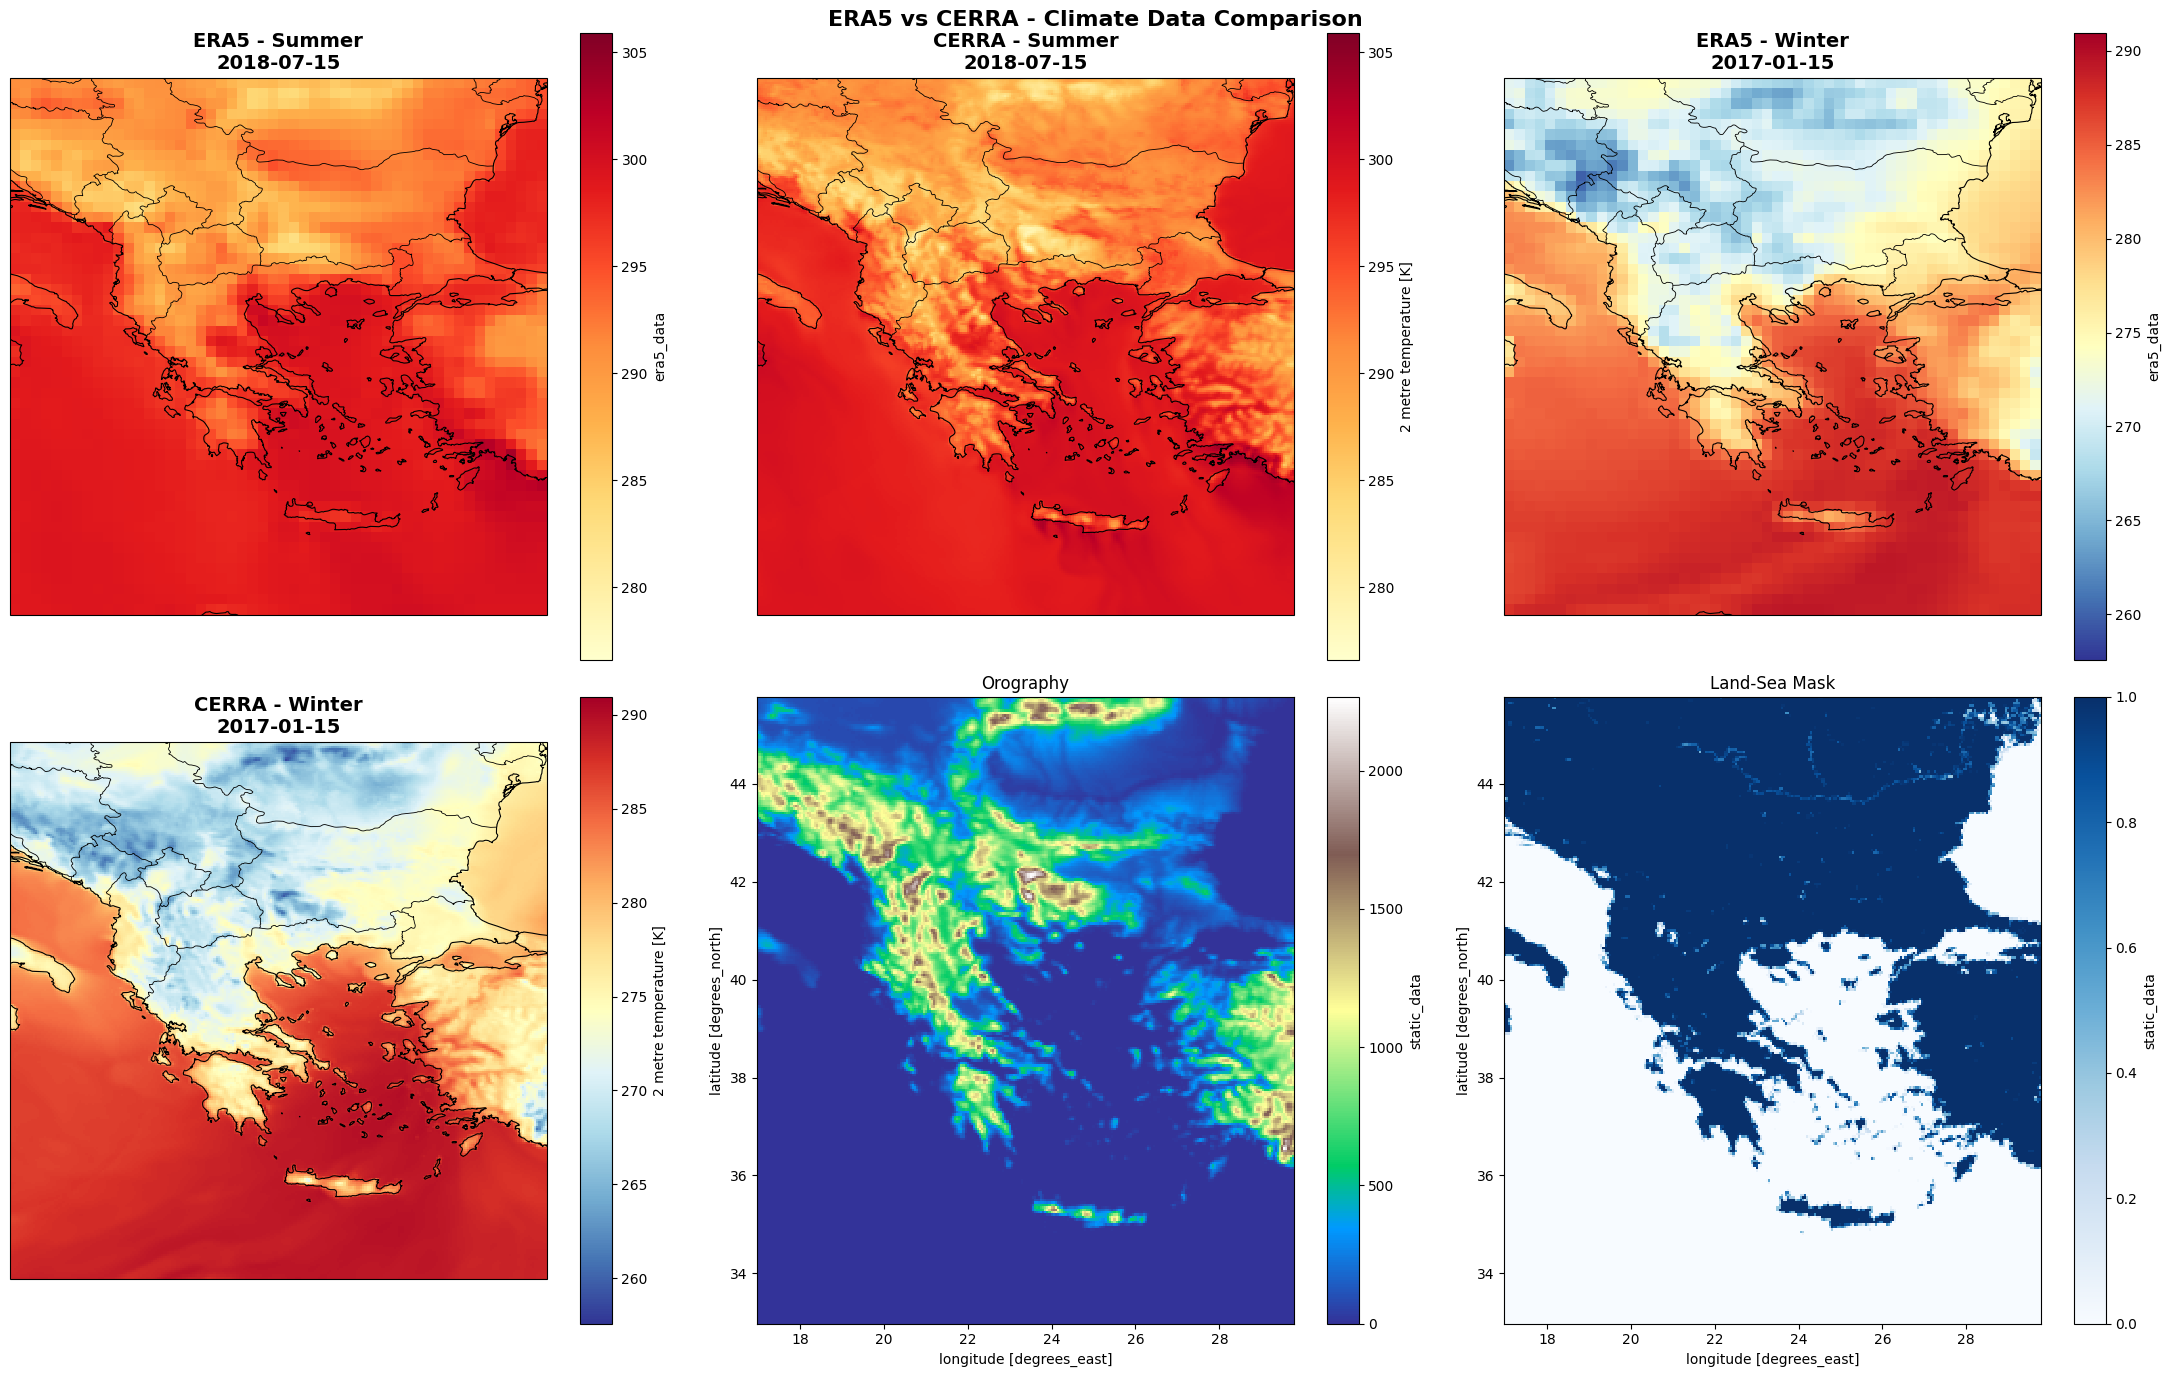

In [10]:
# ==============================================================================
# COMPARATIVE ANALYSIS: ERA5 VS CERRA PLOTS
# ==============================================================================
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import yaml
import os

# Load configuration
with open('config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Load datasets
era5_ds = xr.open_dataset(os.path.join(cfg['paths']['combined'], "ERA5_2010_2021_BCHW.nc"))
cerra_ds = xr.open_dataset(os.path.join(cfg['paths']['root'], "Cerra_2010_2021_BCHW.nc"))
static_ds = xr.open_dataset(os.path.join(cfg['paths']['root'], "CERRA_Greece_Static_B1_CHW.nc"))

summer_date, winter_date = "2018-07-15", "2017-01-15"
fig = plt.figure(figsize=(22, 14))

# Helper function to plot maps
def plot_map(data, ax, title, cmap, vmin, vmax):
    data.plot(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=True)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6)

# ====================== SUMMER ======================
s_era5 = era5_ds.era5_data.isel(channel=0).sel(time=summer_date, method='nearest')
s_cerra = cerra_ds.cerra_data.isel(channel=0).sel(time=summer_date, method='nearest')
vmin_s, vmax_s = float(min(s_era5.min(), s_cerra.min()))-1, float(max(s_era5.max(), s_cerra.max()))+1

plot_map(s_era5, plt.subplot(2, 3, 1, projection=ccrs.PlateCarree()), f'ERA5 - Summer\n{summer_date}', 'YlOrRd', vmin_s, vmax_s)
plot_map(s_cerra, plt.subplot(2, 3, 2, projection=ccrs.PlateCarree()), f'CERRA - Summer\n{summer_date}', 'YlOrRd', vmin_s, vmax_s)

# ====================== WINTER ======================
w_era5 = era5_ds.era5_data.isel(channel=0).sel(time=winter_date, method='nearest')
w_cerra = cerra_ds.cerra_data.isel(channel=0).sel(time=winter_date, method='nearest')
vmin_w, vmax_w = float(min(w_era5.min(), w_cerra.min()))-1, float(max(w_era5.max(), w_cerra.max()))+1

plot_map(w_era5, plt.subplot(2, 3, 3, projection=ccrs.PlateCarree()), f'ERA5 - Winter\n{winter_date}', 'RdYlBu_r', vmin_w, vmax_w)
plot_map(w_cerra, plt.subplot(2, 3, 4, projection=ccrs.PlateCarree()), f'CERRA - Winter\n{winter_date}', 'RdYlBu_r', vmin_w, vmax_w)

# ====================== STATIC ======================
static_ds.static_data.isel(time=0, channel=0).plot(ax=plt.subplot(2, 3, 5), cmap='terrain').axes.set_title('Orography')
static_ds.static_data.isel(time=0, channel=1).plot(ax=plt.subplot(2, 3, 6), cmap='Blues').axes.set_title('Land-Sea Mask')

plt.suptitle('ERA5 vs CERRA - Climate Data Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("Final_Climate_Comparison.png", dpi=300)
plt.show()

# Clean up
for ds in [era5_ds, cerra_ds, static_ds]: ds.close()